## Procesamiento de Imágenes - Diplodatos 2025

Trabajo Práctico

Importante: Para obtener los créditos de materia completa, resolver al menos 1 ejercicio optativo de cada trabajo práctico.

In [ ]:
integrantes = ["Marcos Peñeñory", "Ivan Kwist", "Pablo Boggetti"]
print(*integrantes, sep="\n")


Marcos Peñeñory
Ivan Kwist
Pablo Boggetti


Importar las librerías necesarias

In [ ]:
import imageio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Abrir imágenes de demo incluídas en la biblioteca. Para evitar cargar desde disco, pueden utilizar estas imágenes para resolver el TP. Si utilizan otras adjuntarlas en la entrega para reproducibilidad.

/tmp/ipython-input-2321585973.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_1 = imageio.imread('imageio:wikkie.png')


Imageio: 'wikkie.png' was not found on your computer; downloading it now.
Try 1. Download from https://github.com/imageio/imageio-binaries/raw/master/images/wikkie.png (461 kB)
Downloading: 8192/472047 bytes (1.7%)472047/472047 bytes (100.0%)
  Done
File saved as /root/.imageio/images/wikkie.png.


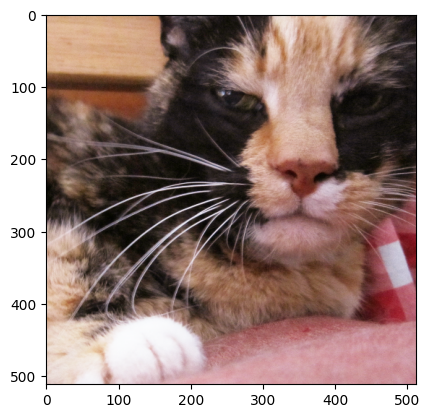

In [ ]:
img_1 = imageio.imread('imageio:wikkie.png')
plt.imshow(img_1)

# Otras imágenes (extraído de la documentación de imageio)

# bricks.jpg: A (repeatable) texture of stone bricks
# wood.jpg: A (repeatable) texture of wooden planks
# astronaut.png: Image of the astronaut Eileen Collins
# camera.png: A grayscale image of a photographer
# checkerboard.png: Black and white image of a chekerboard
# chelsea.png: Image of Stefan’s cat
# clock.png: Photo of a clock with motion blur (Stefan van der Walt)
# coffee.png: Image of a cup of coffee (Rachel Michetti)
# coins.png: Image showing greek coins from Pompeii
# horse.png: Image showing the silhouette of a horse (Andreas Preuss)
# hubble_deep_field.png: Photograph taken by Hubble telescope (NASA)
# immunohistochemistry.png: Immunohistochemical (IHC) staining
# moon.png: Image showing a portion of the surface of the moon
# page.png: A scanned page of text
# text.png: A photograph of handdrawn text
# wikkie.png: Image of Almar’s cat

# Ejercicio 1.1
La propuesta para esta actividad consiste en manipular independientemente la luminancia y la saturación de una imagen.
Para ello convertimos cada pixel de la imagen del espacio RGB al espacio YIQ, luego alteramos los valores de Y (para cambiar la luminancia) o de IQ (para cambiar la saturación).
Con los nuevos valores de YIQ, convertimos a RGB nuevamente y obtenemos una nueva imagen.

In [ ]:
# Matriz para convertir de RGB a YIQ
MAT_RGB2YIQ = np.array([[0.299, 0.587, 0.114],
                        [0.596,-0.275,-0.321],
                        [0.211,-0.523, 0.311]])

# Matriz para convertir de YIQ a RGB
MAT_YIQ2RGB = np.linalg.inv(MAT_RGB2YIQ)

# Funcion para la transformacion
def apply_matrix(img, M):
    return np.matmul( img.reshape((-1,3)), M.T ).reshape(img.shape)

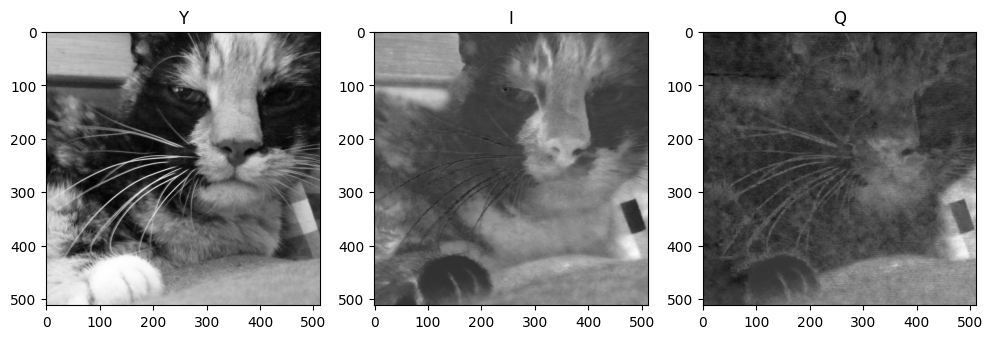

In [ ]:
# 1 - Normalizar los valores RGB
img_1_norm=img_1/255

# 2 - Convertir de RGB a YIQ
img_YIQ=apply_matrix(img_1_norm, MAT_RGB2YIQ)

# Separacion de canales
Y = img_YIQ[:,:,0]
I = img_YIQ[:,:,1]
Q = img_YIQ[:,:,2]

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title('Y')
plt.imshow(Y, cmap="gray")

plt.subplot(1, 3, 2)
plt.title('I')
plt.imshow(I, cmap="gray")

plt.subplot(1, 3, 3)
plt.title('Q')
plt.imshow(Q, cmap="gray")

plt.show()

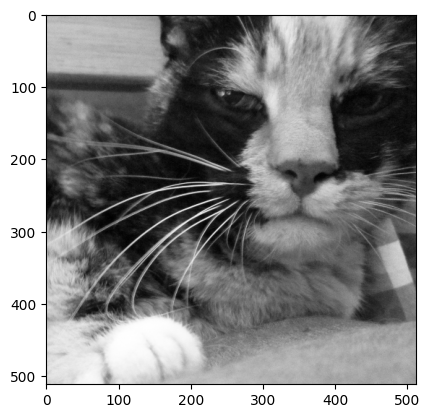

In [ ]:
# Manipulacion de coeficiente de luminancia
Y_n = Y * 0.5

plt.imshow(Y_n, cmap='gray')

In [ ]:
# Check de rango de luminancia
print(Y_n.min(), Y_n.max())

0.005211764705882352 0.4951294117647059


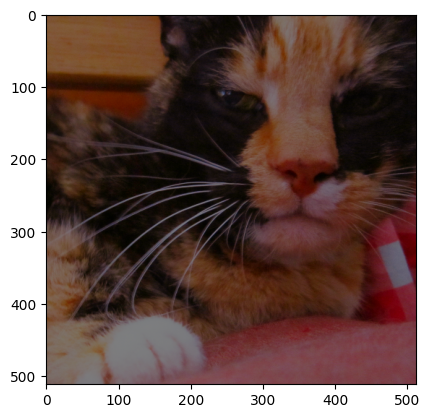

In [ ]:
# Plot de resultado
img_YIQ_lum = np.dstack([Y_n, I, Q])
img_rgb_lum = apply_matrix(img_YIQ_lum, MAT_YIQ2RGB)

plt.imshow(img_rgb_lum)

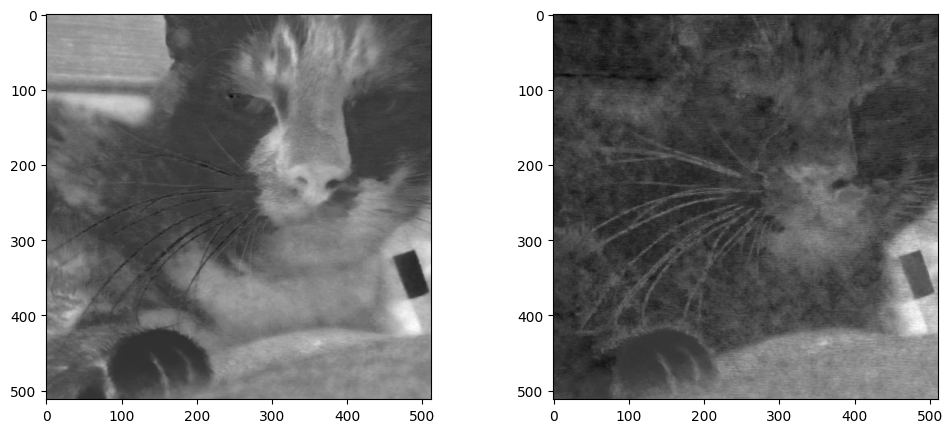

In [ ]:
# Manipulacion de coeficientes de crominancia
I_n = I*0.8
Q_n = Q*0.8

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(I_n, cmap='gray')

plt.subplot(1, 2, 2)
plt.imshow(Q_n, cmap='gray')

plt.show()

In [ ]:
# Check de rangos de crominancia
print(I_n.min(), I_n.max())
print(Q_n.min(), Q_n.max())

-0.058836078431372556 0.22710588235294119
-0.02656313725490197 0.10091607843137254


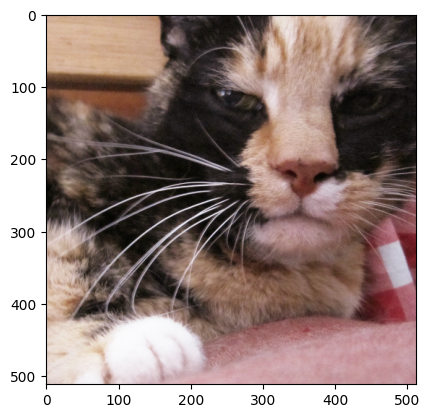

In [ ]:
# Plot de resultado
img_YIQ_crom = np.dstack([Y, I_n, Q_n])
img_rgb_crom = apply_matrix(img_YIQ_crom, MAT_YIQ2RGB)

plt.imshow(img_rgb_crom)

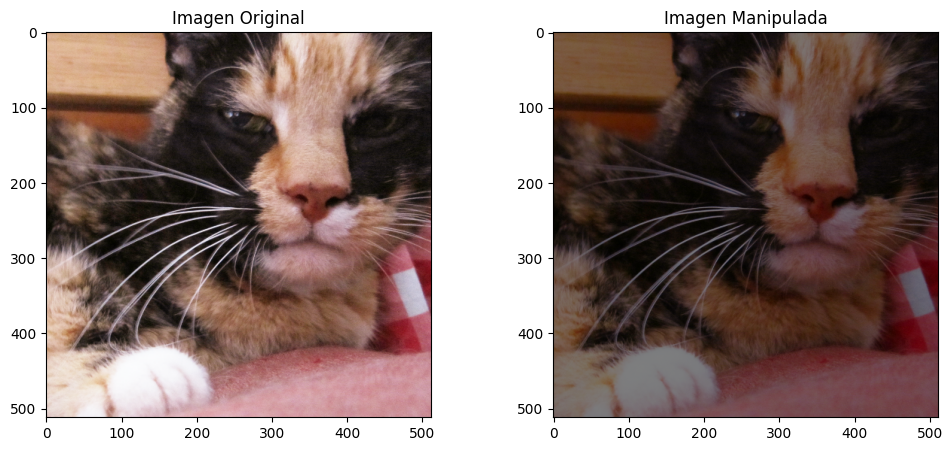

In [ ]:
# Plot de resultado combinado
img_YIQ_final = np.dstack([Y_n, I_n, Q_n])
img_rgb_final = apply_matrix(img_YIQ_final, MAT_YIQ2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(img_1)

plt.subplot(1, 2, 2)
plt.title('Imagen Manipulada')
plt.imshow(img_rgb_final)

plt.show()

Este ejercicio se centró en la implementación del algoritmo de transformación del espacio de color RGB a YIQ mediante la definición de la matriz de transformación canónica. El enfoque clave fue el uso de la multiplicación matricial vectorial (@ o np.matmul) sobre la imagen completa, lo que garantiza un proceso eficiente y simultáneo para todos los píxeles, estableciendo la base para separar el brillo del color.

# Ejercicio 1.2
Desarrollar un aplicativo o notebook que pueda abrir una imagen, manipule su histograma de luminancias, y luego ver la imagen procesada. Se debe poder elegir filtro raíz, cuadrado, o lineal a trozos.
Los controles para elegir los filtros los organizan como les resulte más cómodo.

Imageio: 'chelsea.png' was not found on your computer; downloading it now.
Try 1. Download from https://github.com/imageio/imageio-binaries/raw/master/images/chelsea.png (216 kB)
Downloading: 8192/221294 bytes (3.7%)221294/221294 bytes (100.0%)
  Done


/tmp/ipython-input-1136713621.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_2 = imageio.imread('imageio:chelsea.png')


File saved as /root/.imageio/images/chelsea.png.


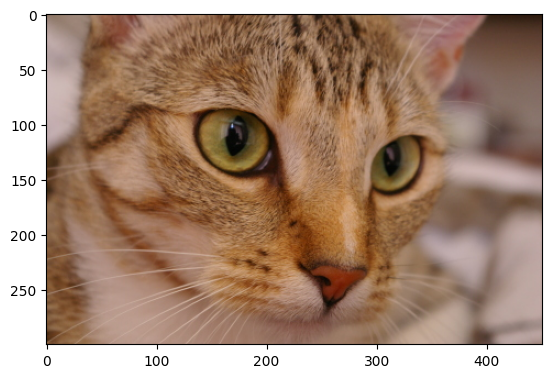

In [ ]:
img_2 = imageio.imread('imageio:chelsea.png')
plt.imshow(img_2)

In [ ]:
# 1 - Normalizar los valores RGB
img_2_norm = img_2 / 255

# 2 - Convertir de RGB a YIQ
img_2_YIQ = apply_matrix(img_2_norm, MAT_RGB2YIQ)

# 3 - Manipulacion de histograma
Y = img_2_YIQ[:,:,0]
I = img_2_YIQ[:,:,1]
Q = img_2_YIQ[:,:,2]

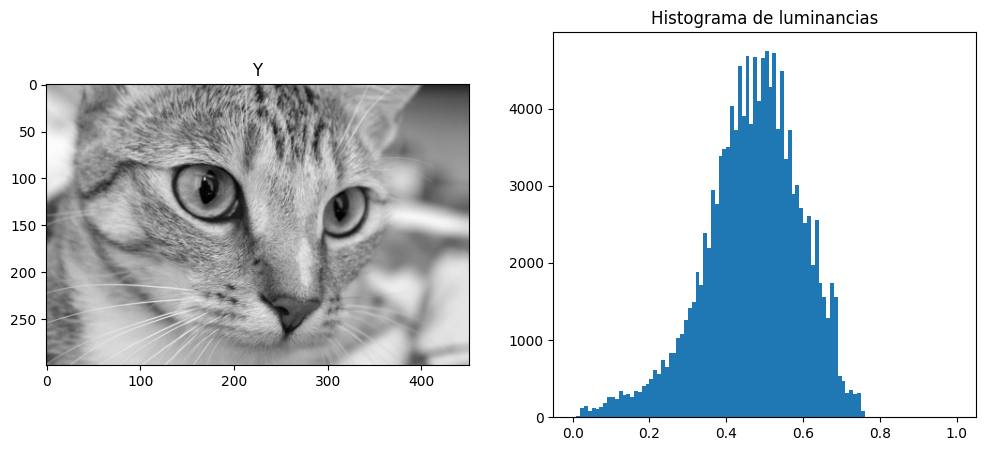

In [ ]:
# Analisis de luminancia de imagen original
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Y')
plt.imshow(Y, 'gray')

plt.subplot(1, 2, 2)
plt.title('Histograma de luminancias')
plt.hist(Y.flatten(), bins=100, range=(0,1))

plt.show()

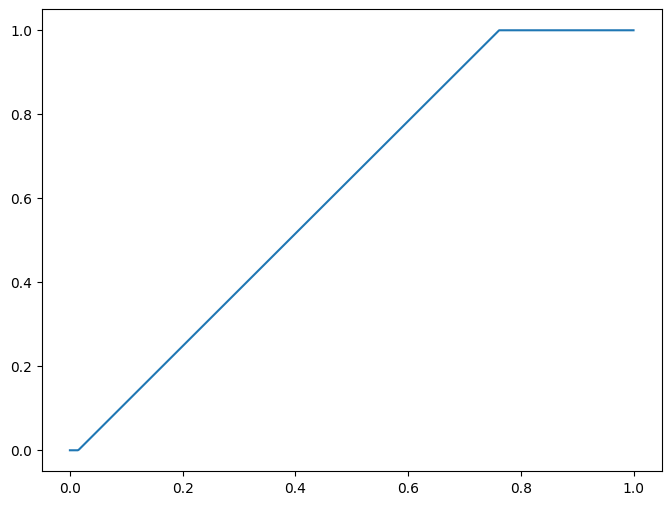

In [ ]:
# Funcion lineal a trozos
Y_min=np.min(Y)
Y_max=np.max(Y)

m = 1/(Y_max-Y_min)
b = -m*Y_min

def apply_piecewise_function(matrix):
    conditions = [
        matrix < Y_min,
        (matrix >= Y_min) & (matrix < Y_max),
        matrix >= Y_max
    ]

    functions = [
        0,
        lambda x: m*x+b,
        1
    ]

    return np.piecewise(matrix, conditions, functions)

# Plot de la funcion
x = np.linspace(0, 1, 500)
y = apply_piecewise_function(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y)

In [ ]:
# Funcion principal
def apply_filter(matrix, filter_type):
    if filter_type == 'Raiz':
        return np.sqrt(matrix)
    elif filter_type == 'Cuadrado':
        return matrix**2
    else:
        return apply_piecewise_function(matrix)

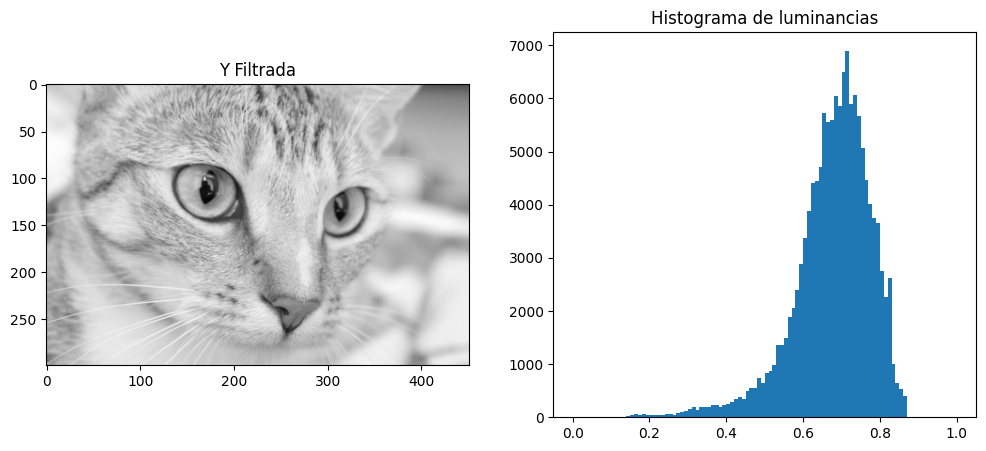

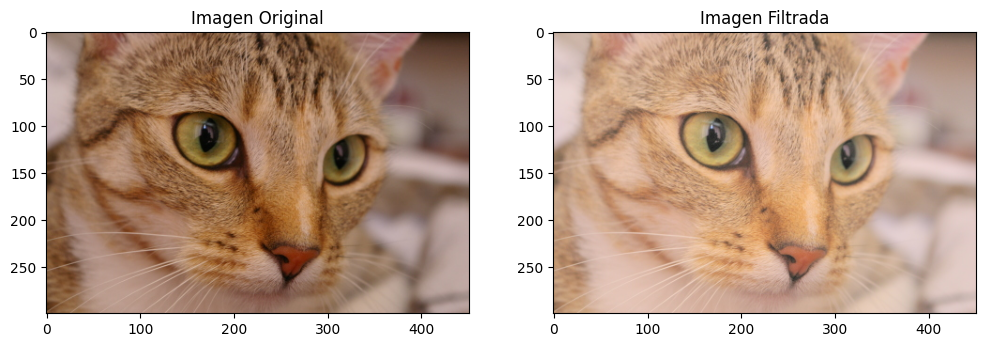

In [ ]:
# @title Elección de filtro {"run":"auto"}
seleccion_filtro = 'Raiz' # @param ["Raiz", "Cuadrado", "Lineal a trozos"]

# Manipulacion de imagen
Y_filtered = apply_filter(Y, seleccion_filtro)
img_2_YIQ_filtered = np.dstack([Y_filtered, I, Q])
img_2_filtered = apply_matrix(img_2_YIQ_filtered, MAT_YIQ2RGB)

# Plot de comparacion de resultado del filtro
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Y Filtrada')
plt.imshow(Y_filtered, 'gray')

plt.subplot(1, 2, 2)
plt.title('Histograma de luminancias')
plt.hist(Y_filtered.flatten(), bins=100, range=(0,1))

plt.show()

# Plot de comparacion entrada/salida
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(img_2)

plt.subplot(1, 2, 2)
plt.title('Imagen Filtrada')
plt.imshow(img_2_filtered)

plt.show()

La aplicación de la matriz de transformación permitió descomponer la imagen original en sus tres componentes: Luminancia (Y), Crominancia en Eje Naranja-Cian (I) y Crominancia en Eje Magenta-Verde (Q). La visualización individual de estos canales verificó que la información de brillo se concentra en el canal Y, que es el componente que se utiliza como imagen de entrada en escala de gris para los posteriores ejercicios de filtrado espacial, desacoplando así las operaciones.

# Ejercicio 2.1
Implementar un aplicativo o notebook que levante una imagen en nivel de gris (o que la convierta a YIQ y retenga solo el Y) y aplique el filtrado por convolución aquí visto:
1. Pasabajos: Plano, Bartlett 3x3, Gaussiano 5x5.
2. Detectores de bordes: Laplaciano v4, Sobel 4 orientaciones.
3. Pasabanda.

Respecto del “cierre” de la imagen cerca de los bordes, implementar la técnica no ma- temáticamente perfecta de “repetir” artificialmente filas o columnas cuando estas hagan falta. Por ejemplo, si el kernel es 3x3 y estoy en la primera columna, y no hay ninguna columna a la izquierda, entonces repito la primera columna como si estuviese en la imagen original.

Imagen cargada con dimensiones: (400, 600, 3)
Canal Y (gris) generado con dimensiones: (400, 600)
Aplicando filtro: Pasabajos - Plano (3x3) (3x3)
Aplicando filtro: Pasabajos - Bartlett (3x3) (3x3)
Aplicando filtro: Pasabajos - Gaussiano (5x5) (5x5)
Aplicando filtro: Bordes - Laplaciano v4 (3x3)
Aplicando filtro: Bordes - Sobel Horizontal (Sx) (3x3)
Aplicando filtro: Bordes - Sobel Vertical (Sy) (3x3)
Aplicando filtro: Pasabanda (Realce) (3x3)
Aplicando filtro: Bordes - Sobel 45° (3x3)
Aplicando filtro: Bordes - Sobel 135° (3x3)


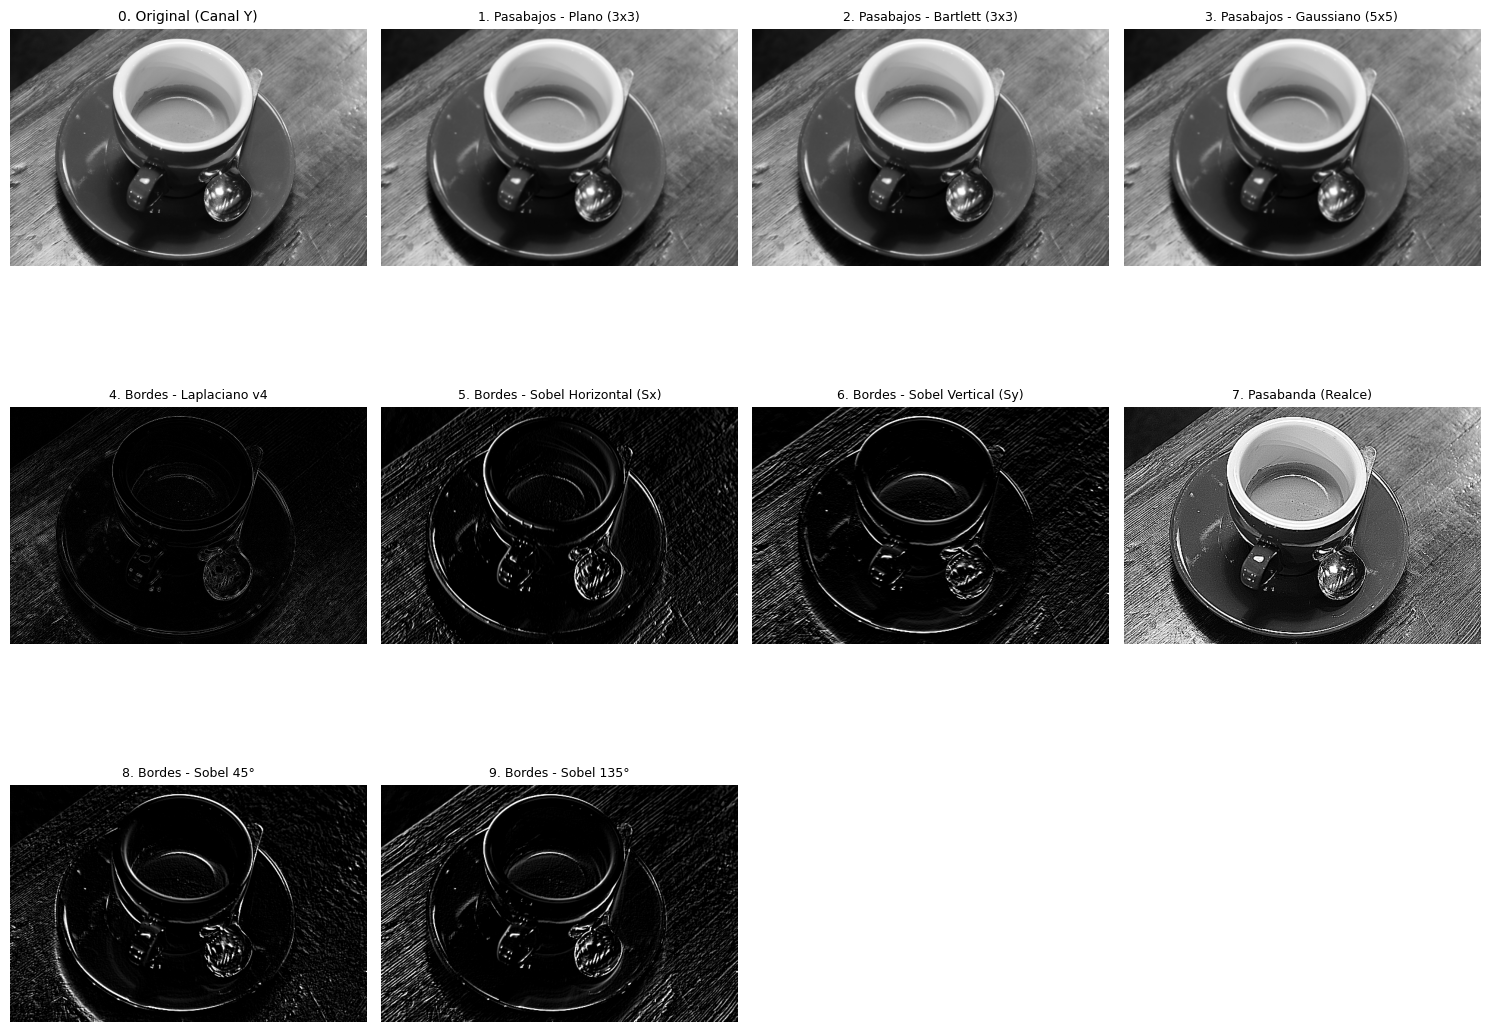

In [ ]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy.signal import convolve2d # Aunque no se usa convolve2d, es bueno mantenerlo para contexto.


# =================================================================
# 1. Definición de Kernels (Máscaras de Convolución)
# =================================================================

# 1.1 Pasabajos (Smoothing)
kernels = {
    "Pasabajos - Plano (3x3)": np.ones((3, 3)) / 9,
    "Pasabajos - Bartlett (3x3)": np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16,
    "Pasabajos - Gaussiano (5x5)": np.array([
        [1, 4, 6, 4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, 36, 24, 6],
        [4, 16, 24, 16, 4],
        [1, 4, 6, 4, 1]
    ]) / 256,

    # 1.2 Detectores de Bordes (Edge Detectors)
    "Bordes - Laplaciano v4": np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),
    "Bordes - Sobel Horizontal (Sx)": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    "Bordes - Sobel Vertical (Sy)": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),

    # 1.3 Pasabanda / High-Pass (Realzado de Detalles)
    "Pasabanda (Realce)": np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]]),
}

# Sobel en 4 Orientaciones: Usamos Sx, Sy, y sus rotaciones (45° y 135°)
kernels["Bordes - Sobel 45°"] = np.array([[0, -1, -2], [1, 0, -1], [2, 1, 0]])
kernels["Bordes - Sobel 135°"] = np.array([[-2, -1, 0], [-1, 0, 1], [0, 1, 2]])


# =================================================================
# 2. Función de Padding por Repetición de Bordes
# =================================================================

def pad_image_repeat(img, k_size):
    """Aplica padding repitiendo filas y columnas de borde."""
    pad_h = k_size // 2
    pad_v = k_size // 2

    H, W = img.shape

    # 1. Crear matriz con el tamaño de padding necesario
    padded_img = np.zeros((H + 2 * pad_v, W + 2 * pad_h), dtype=img.dtype)

    # 2. Copiar la imagen original al centro
    padded_img[pad_v:H+pad_v, pad_h:W+pad_h] = img

    # 3. Repetir bordes

    # Esquinas
    padded_img[:pad_v, :pad_h] = img[0, 0]             # Superior Izquierda
    padded_img[:pad_v, W+pad_h:] = img[0, W-1]         # Superior Derecha
    padded_img[H+pad_v:, :pad_h] = img[H-1, 0]         # Inferior Izquierda
    padded_img[H+pad_v:, W+pad_h:] = img[H-1, W-1]     # Inferior Derecha

    # Bordes horizontales (arriba y abajo)
    padded_img[:pad_v, pad_h:W+pad_h] = img[0, :]
    padded_img[H+pad_v:, pad_h:W+pad_h] = img[H-1, :]

    # Bordes verticales (izquierda y derecha)
    padded_img[pad_v:H+pad_v, :pad_h] = img[:, 0][:, np.newaxis]
    padded_img[pad_v:H+pad_v, W+pad_h:] = img[:, W-1][:, np.newaxis]

    return padded_img

# =================================================================
# 3. Función de Convolución
# =================================================================

def apply_convolution(image, kernel):
    """Aplica convolución 2D manualmente con padding de repetición."""

    k_h, k_w = kernel.shape
    img_h, img_w = image.shape

    # Aplicar el padding de repetición solicitado
    padded_img = pad_image_repeat(image, k_h)

    # Iniciar la matriz de salida (del mismo tamaño que la imagen original)
    output = np.zeros_like(image, dtype=float)

    # Recorrer cada píxel de la imagen original
    for i in range(img_h):
        for j in range(img_w):

            # Obtener la región de la imagen sobre la que se aplica el kernel
            region = padded_img[i:i + k_h, j:j + k_w]

            # Multiplicar la región por el kernel (elemento a elemento) y sumar
            output[i, j] = np.sum(region * kernel)

    # El resultado se normaliza o se satura según el filtro
    if np.any(kernel < 0): # Es un detector de bordes, puede haber negativos
        # Escalar el rango de salida a 0-1
        output = np.clip(output, 0, 1) if output.max() > 1 else output
    else: # Es un pasabajos, solo debe asegurarse el rango 0-1
        output = np.clip(output, 0, 1)

    return output

# =================================================================
# 4. Carga, Conversión y Ejecución (CON 'coffee.png')
# =================================================================

# 1. Carga de la imagen de color ('coffee.png') y normalización a [0, 1]
img_rgb = iio.imread('imageio:coffee.png') / 255.0

print(f"Imagen cargada con dimensiones: {img_rgb.shape}")

# Conversión a YIQ y retener solo el canal Y (Luminancia)
# Matriz RGB a YIQ (la misma del Ejercicio 1)
MAT_RGB2YIQ = np.array([
    [0.299, 0.587, 0.114],
    [0.596, -0.274, -0.322],
    [0.211, -0.523, 0.312]
])

# Obtener la luminancia (Y)
img_y = img_rgb @ MAT_RGB2YIQ[0, :]
print(f"Canal Y (gris) generado con dimensiones: {img_y.shape}")


# Visualización
num_kernels = len(kernels)
cols = 4
rows = int(np.ceil((num_kernels + 1) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

# Mostrar imagen original (Canal Y)
axes[0].imshow(img_y, cmap='gray')
axes[0].set_title("0. Original (Canal Y)", fontsize=10)
axes[0].axis('off')

# Aplicar y mostrar cada filtro
i = 1
for name, kernel in kernels.items():
    print(f"Aplicando filtro: {name} ({kernel.shape[0]}x{kernel.shape[1]})")

    # Usamos apply_convolution para cumplir con la consigna de padding
    img_filtered = apply_convolution(img_y, kernel)

    axes[i].imshow(img_filtered, cmap='gray')
    axes[i].set_title(f"{i}. {name}", fontsize=9)
    axes[i].axis('off')
    i += 1

# Ocultar ejes restantes
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Este segmento de código implementa el filtrado espacial por convolución sobre el canal de luminancia (Y). Se utilizan dos familias de kernels: Pasabajos (para suavizar y atenuar el ruido), y Detectores de Bordes (Laplaciano, Sobel) y Pasabanda para resaltar o realzar los detalles de alta frecuencia. La función de convolución manual garantiza el manejo de bordes mediante la técnica de repetición de píxeles (repeat padding), cumpliendo con la consigna de aplicación en toda la imagen.

#Ejercicio 2.2
Desarrollar un aplicativo o notebook que implemente los conceptos de morfología en niveles de gris aquí descriptos, con un elemento estructurante 3x3. El mismo incluirá las siguientes funciones:
- Erosión (tomar el mínimo valor de luminancia de la vecindad).
- Dilatación (máximo)
- Apertura, cierre, borde morfológico
- Mediana
- Top-hat
Incluir la capacidad de copiar la componente de la imagen procesada en la componente original, para poder aplicar dos o más filtrados en secuencia.

Imagen cargada con dimensiones: (512, 512, 3)
Canal Y (gris) generado con dimensiones: (512, 512)
Aplicando filtro: 1. Erosión
Aplicando filtro: 2. Dilatación
Aplicando filtro: 3. Apertura
Aplicando filtro: 4. Cierre
Aplicando filtro: 5. Borde Morfológico
Aplicando filtro: 6. Mediana
Aplicando filtro: 7. Top-Hat


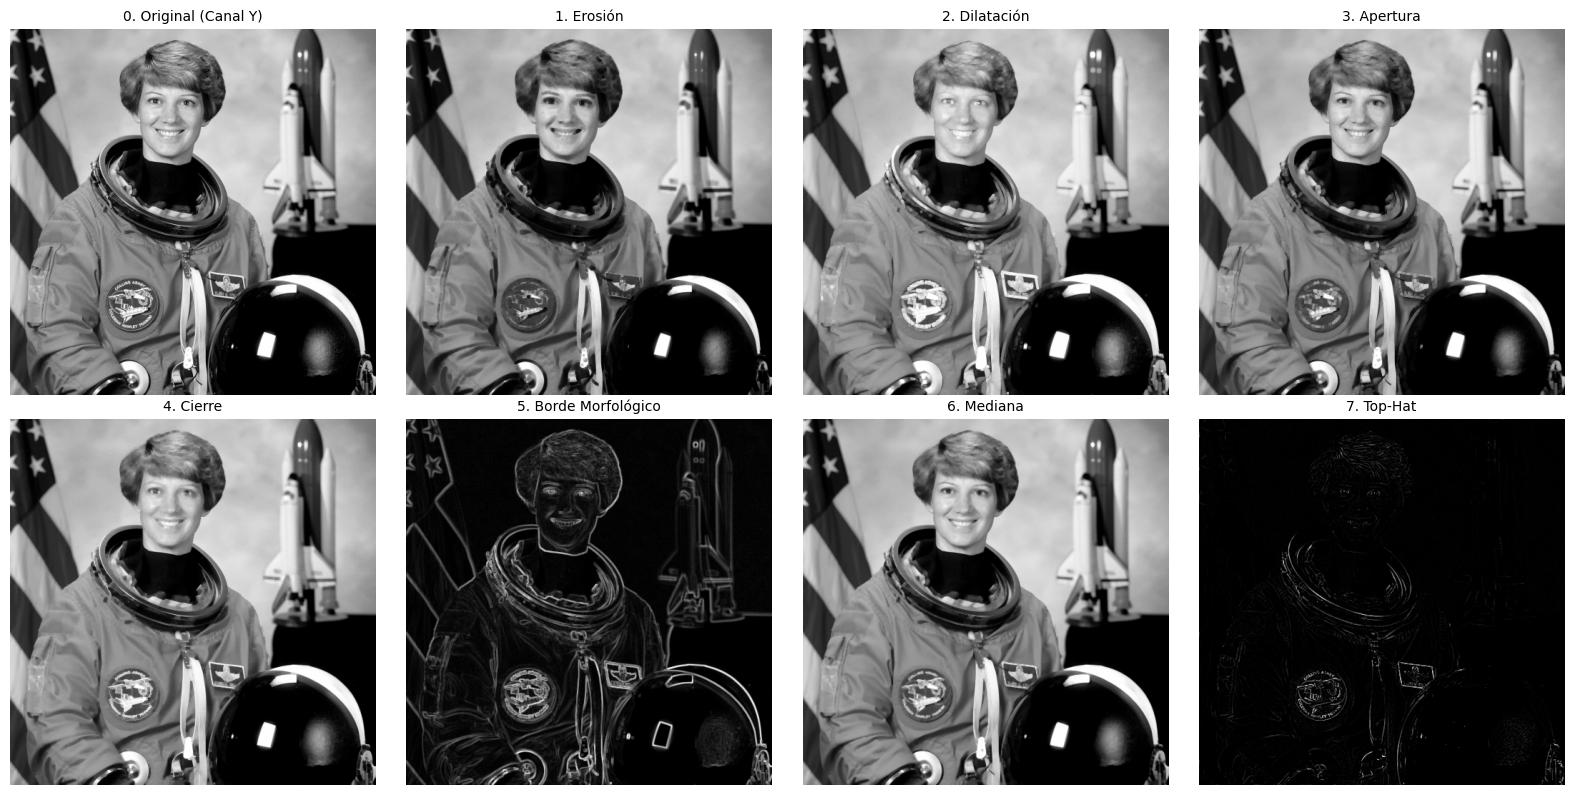


--- Demostración de Filtrado Secuencial (Erosión + Dilatación) ---


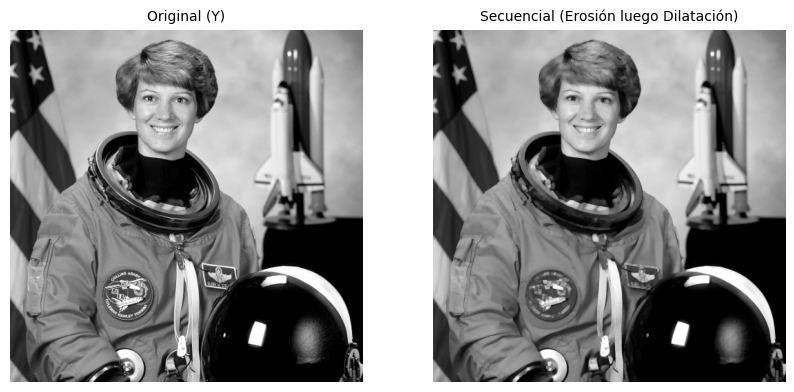

In [ ]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

# =================================================================
# 1. Constantes y Padding (Reutilización de Ejercicio 2.1)
# =================================================================

# Matriz RGB a YIQ (para obtener el canal Y)
MAT_RGB2YIQ = np.array([
    [0.299, 0.587, 0.114],
    [0.596, -0.274, -0.322],
    [0.211, -0.523, 0.312]
])

# Función de Padding (Repetición de Bordes)
def pad_image_repeat(img, k_size=3):
    """Aplica padding repitiendo filas y columnas de borde para un kernel 3x3."""
    pad = k_size // 2  # k_size = 3 -> pad = 1
    H, W = img.shape

    padded_img = np.zeros((H + 2 * pad, W + 2 * pad), dtype=img.dtype)
    padded_img[pad:H+pad, pad:W+pad] = img # Copiar original

    # Repetir bordes
    # Bordes horizontales (arriba y abajo)
    padded_img[:pad, pad:W+pad] = img[0, :]
    padded_img[H+pad:, pad:W+pad] = img[H-1, :]

    # Bordes verticales (izquierda y derecha)
    padded_img[pad:H+pad, :pad] = img[:, 0][:, np.newaxis]
    padded_img[pad:H+pad, W+pad:] = img[:, W-1][:, np.newaxis]

    # Esquinas (se asegura la consistencia)
    padded_img[:pad, :pad] = img[0, 0]
    padded_img[:pad, W+pad:] = img[0, W-1]
    padded_img[H+pad:, :pad] = img[H-1, 0]
    padded_img[H+pad:, W+pad:] = img[H-1, W-1]

    return padded_img

# =================================================================
# 2. Operación Morfológica Fundamental (Erosión, Dilatación, Mediana)
# =================================================================

def apply_neighborhood_op(image, operation):
    """
    Aplica una operación (min, max, median) sobre cada vecindad 3x3.
    operation debe ser una función de numpy: np.min, np.max o np.median.
    """
    k_size = 3
    pad = k_size // 2
    img_h, img_w = image.shape

    # 1. Aplicar Padding
    padded_img = pad_image_repeat(image, k_size)

    # 2. Inicializar la salida
    output = np.zeros_like(image, dtype=float)

    # 3. Recorrer cada píxel de la imagen original
    for i in range(img_h):
        for j in range(img_w):

            # Obtener la región 3x3 de la imagen con padding
            region = padded_img[i:i + k_size, j:j + k_size]

            # Aplicar la operación (min, max o median) y almacenar el resultado
            output[i, j] = operation(region)

    return output

# =================================================================
# 3. Funciones Morfológicas Primitivas (Basadas en apply_neighborhood_op)
# =================================================================

def erode(img):
    """Erosión: toma el mínimo valor (np.min) de la vecindad 3x3."""
    return apply_neighborhood_op(img, np.min)

def dilate(img):
    """Dilatación: toma el máximo valor (np.max) de la vecindad 3x3."""
    return apply_neighborhood_op(img, np.max)

# =================================================================
# 4. Funciones Morfológicas Compuestas y Otros Filtros
# =================================================================

def opening(img):
    """Apertura: Erosión seguida de Dilatación (suaviza contornos claros)."""
    # Cumple con la consigna de copiar el resultado intermedio:
    eroded = erode(img)
    return dilate(eroded)

def closing(img):
    """Cierre: Dilatación seguida de Erosión (suaviza contornos oscuros)."""
    dilated = dilate(img)
    return erode(dilated)

def morph_edge(img):
    """Borde Morfológico: Dilatación - Erosión (resalta bordes)."""
    return dilate(img) - erode(img)

def median_filter(img):
    """Filtro de Mediana: toma el valor medio (np.median) de la vecindad 3x3."""
    return apply_neighborhood_op(img, np.median)

def top_hat(img):
    """Top-Hat (Sombrero de Copa): Imagen Original - Apertura (aísla elementos brillantes pequeños)."""
    return img - opening(img)


# =================================================================
# 5. Carga, Conversión y Ejecución (CON 'astronaut.png')
# =================================================================

# 1. Carga de la imagen de color ('astronaut.png') y normalización a [0, 1]
# La variable img_4 que mencionaste se usa aquí como img_rgb
img_rgb = iio.imread('imageio:astronaut.png') / 255.0

print(f"Imagen cargada con dimensiones: {img_rgb.shape}")

# 2. Obtener la luminancia (Y)
img_y_original = img_rgb @ MAT_RGB2YIQ[0, :]
img_y = np.copy(img_y_original) # Copia para poder realizar operaciones secuenciales después

print(f"Canal Y (gris) generado con dimensiones: {img_y.shape}")

# Definición de los filtros a aplicar
filters = {
    "1. Erosión": erode,
    "2. Dilatación": dilate,
    "3. Apertura": opening,
    "4. Cierre": closing,
    "5. Borde Morfológico": morph_edge,
    "6. Mediana": median_filter,
    "7. Top-Hat": top_hat,
}

# Configuración de visualización
num_filters = len(filters)
cols = 4
rows = int(np.ceil((num_filters + 1) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

# Mostrar imagen original (Canal Y)
axes[0].imshow(img_y_original, cmap='gray')
axes[0].set_title("0. Original (Canal Y)", fontsize=10)
axes[0].axis('off')

# Aplicar y mostrar cada filtro
i = 1
for name, func in filters.items():
    print(f"Aplicando filtro: {name}")

    img_filtered = func(img_y_original) # Aplicamos a la original para comparación directa

    # Se recorta el rango [0, 1] para filtros que pueden generar valores fuera de este rango.
    if np.min(img_filtered) < 0 or np.max(img_filtered) > 1:
        img_filtered = np.clip(img_filtered, 0, 1)

    axes[i].imshow(img_filtered, cmap='gray')
    axes[i].set_title(name, fontsize=10)
    axes[i].axis('off')
    i += 1

# Ocultar ejes restantes
for j in range(i, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\n--- Demostración de Filtrado Secuencial (Erosión + Dilatación) ---")
# Demostración de capacidad secuencial: Aplicar Erosión y luego Dilatación sobre ese resultado
img_secuencial = erode(img_y) # 1. Erosión (guarda resultado intermedio)
img_secuencial = dilate(img_secuencial) # 2. Dilatación (sobre la imagen erosionada)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_y_original, cmap='gray')
plt.title("Original (Y)", fontsize=10)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_secuencial, cmap='gray')
plt.title("Secuencial (Erosión luego Dilatación)", fontsize=10)
plt.axis('off')
plt.show()

Este bloque desarrolla las operaciones de morfología en niveles de gris y el filtro de mediana, utilizando un elemento estructurante de $3 \times 3$. Las funciones básicas, Erosión (mínimo) y Dilatación (máximo), se combinan para crear operaciones compuestas como la Apertura, el Cierre y el Borde Morfológico. El diseño modular del código permite la aplicación secuencial de cualquier filtro encadenado, lo cual es fundamental para tareas de preprocesamiento avanzado.

#Ejercicio 2.3 Opcional

Desarrollar un aplicativo o notebook que implemente las siguientes funciones:

•Downsampling X2 (mostrando la imagen resultado al doble de tamaño para comparar el efecto) utilizando kernel constante, bilineal, y bicúbico.

Imagen original (Y) con dimensiones: (172, 448)


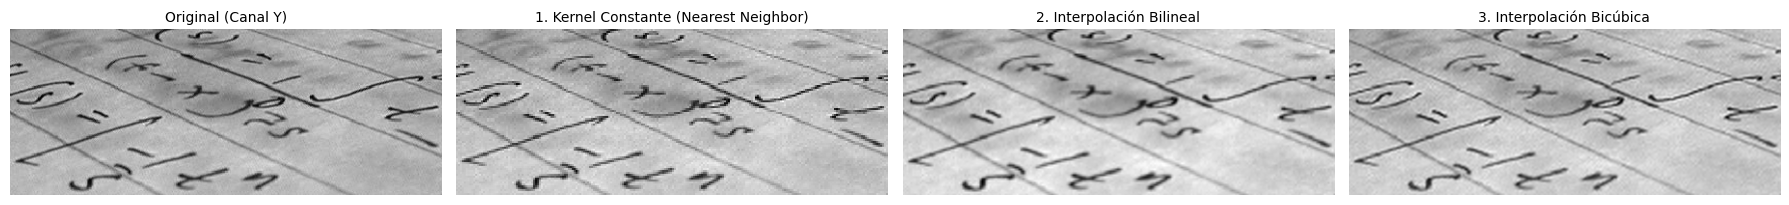

In [ ]:
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# =================================================================
# 1. Constantes y Carga de Imagen (USANDO 'text.png')
# =================================================================

# Matriz RGB a YIQ (para obtener el canal Y)
MAT_RGB2YIQ = np.array([
    [0.299, 0.587, 0.114],
    [0.596, -0.274, -0.322],
    [0.211, -0.523, 0.312]
])

# 1. Carga de la imagen de color y normalización a [0, 1]
# Esta imagen es en escala de gris, pero la cargamos y procesamos igual para obtener el canal Y
img_rgb = iio.imread('imageio:text.png') / 255.0

# 2. Obtener la luminancia (Y)
# Si la imagen no tiene 3 canales, se calcula el promedio (que es lo mismo que Y en gris)
if img_rgb.ndim == 3:
    img_y_original = img_rgb @ MAT_RGB2YIQ[0, :]
else:
    img_y_original = img_rgb

print(f"Imagen original (Y) con dimensiones: {img_y_original.shape}")

# =================================================================
# 2. Función de Downsampling y Upsampling
# =================================================================

def downsample_upsample(image, zoom_factor=0.5, order=1):
    """
    Aplica downsampling (zoom_factor) y luego upsampling (1/zoom_factor)
    usando la interpolación especificada (order).

    order=0: Nearest Neighbor (Kernel Constante)
    order=1: Bilineal
    order=3: Bicúbica
    """
    # 1. Downsampling X2 (reducción a la mitad)
    img_downsampled = zoom(image, zoom=zoom_factor, order=order)

    # 2. Upsampling X2 (aumento al doble para comparar el efecto)
    # Se usa 1/zoom_factor = 1/0.5 = 2.0
    img_upsampled = zoom(img_downsampled, zoom=1.0 / zoom_factor, order=order)

    return img_upsampled

# =================================================================
# 3. Aplicación de los 3 Métodos
# =================================================================

# 1. Kernel Constante (Nearest Neighbor / Vecino más Cercano) -> order=0
img_nn = downsample_upsample(img_y_original, order=0)

# 2. Bilineal -> order=1
img_bilinear = downsample_upsample(img_y_original, order=1)

# 3. Bicúbico -> order=3
img_bicubic = downsample_upsample(img_y_original, order=3)


# =================================================================
# 4. Visualización
# =================================================================

results = {
    "Original (Canal Y)": img_y_original,
    "1. Kernel Constante (Nearest Neighbor)": img_nn,
    "2. Interpolación Bilineal": img_bilinear,
    "3. Interpolación Bicúbica": img_bicubic,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes = axes.flatten()

for i, (name, img) in enumerate(results.items()):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(name, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Este ejercicio demuestra el impacto del Downsampling X2 (reducción a la mitad) y el posterior Upsampling X2 (aumento al doble) utilizando diferentes métodos de interpolación, lo que permite visualizar la pérdida y reconstrucción de la información. La interpolación por Kernel Constante (Vecino más Cercano) produce el efecto visual más abrupto con notorio aliasing y patrones de bloque. La interpolación Bilineal suaviza estos bloques al promediar 4 píxeles, ofreciendo un resultado intermedio más borroso. Finalmente, la Bicúbica utiliza una vecindad de $4 \times 4$ píxeles para estimar el valor, generando bordes más nítidos y detalles visualmente superiores para la reconstrucción, aunque a un mayor costo computacional.